<a href="https://colab.research.google.com/github/NeonLabs146/Image_Processing/blob/main/Image_processing_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 2: Image Enhancement and Filtering - Mathematical Examples

## Table of Contents
1. [Basic Gray Level Transformations](#basic-gray-level-transformations)
2. [Histogram Processing](#histogram-processing)
3. [Spatial Filtering](#spatial-filtering)
4. [Image Magnification](#image-magnification)

---

## 1. BASIC GRAY LEVEL TRANSFORMATIONS

### 1.1 Contrast Stretching

**Definition:** Expand narrow range of input intensities to full output range.

**Formula:**
$$s = \frac{s_{max} - s_{min}}{r_{max} - r_{min}}(r - r_{min}) + s_{min}$$

**Example:**
An image has intensities in range [50, 200]. Stretch to full [0, 255] range.

Given:
- Input range: $r_{min} = 50$, $r_{max} = 200$
- Output range: $s_{min} = 0$, $s_{max} = 255$

For pixel with intensity $r = 100$:
$$s = \frac{255 - 0}{200 - 50}(100 - 50) + 0$$
$$s = \frac{255}{150}(50) + 0$$
$$s = 1.7 \times 50 = 85$$

For pixel with intensity $r = 150$:
$$s = \frac{255}{150}(150 - 50) + 0 = 1.7 \times 100 = 170$$

**Results:**
| Input (r) | Output (s) |
|-----------|-----------|
| 50        | 0         |
| 100       | 85        |
| 150       | 170       |
| 200       | 255       |

**Observation:** Narrow input range [50, 200] expanded to full output [0, 255].

---

### 1.2 Digital Negative

**Definition:** Invert pixel intensities.

**Formula:**
$$s = L - 1 - r$$

where $L$ = number of gray levels (typically 256)

**Example:**
For 8-bit image ($L = 256$):

For pixel $r = 50$:
$$s = 256 - 1 - 50 = 205$$

For pixel $r = 100$:
$$s = 256 - 1 - 100 = 155$$

For pixel $r = 200$:
$$s = 256 - 1 - 200 = 55$$

**Results:**
| Input (r) | Output (s) |
|-----------|-----------|
| 0         | 255       |
| 50        | 205       |
| 100       | 155       |
| 200       | 55        |
| 255       | 0         |

**Visual Effect:** Dark regions (low r) become bright (high s), and vice versa.

---

### 1.3 Thresholding

**Definition:** Convert grayscale to binary image.

**Formula:**
$$s = \begin{cases} 0 & \text{if } r < T \\ L-1 & \text{if } r \geq T \end{cases}$$

**Example:**
For 8-bit image with threshold $T = 128$:

| Input (r) | Output (s) | Reason                |
|-----------|-----------|----------------------|
| 50        | 0         | 50 < 128 → Black     |
| 100       | 0         | 100 < 128 → Black    |
| 128       | 255       | 128 ≥ 128 → White    |
| 150       | 255       | 150 ≥ 128 → White    |
| 200       | 255       | 200 ≥ 128 → White    |

**Sample 3×3 Image:**
```
Input:
100  120  140
110  200  150
90   180  160

Output (T=128):
0    0    255
0    255  255
0    255  255
```

In [ ]:
"""
Image Processing Lab - Unit 2: Image Enhancement and Filtering
Implementation of all operations from scratch using NumPy

Author: Image Processing Lab
Date: November 2025
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

###**Contrast Stretching**

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

In [ ]:
input_range = [50, 200]
output_range = [0, 255]
img = np.array([[50,130,140],[60,50,120],[100,160,200]])

rmin = input_range[0]
rmax = input_range[1]
smin = output_range[0]
smax = output_range[1]

s=(smax-smin)/(rmax-rmin)*(img-rmin)+smin
print(s)

[[  0. 136. 153.]
 [ 17.   0. 119.]
 [ 85. 187. 255.]]


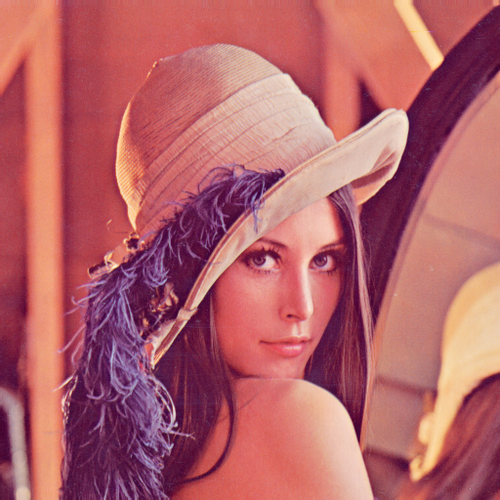

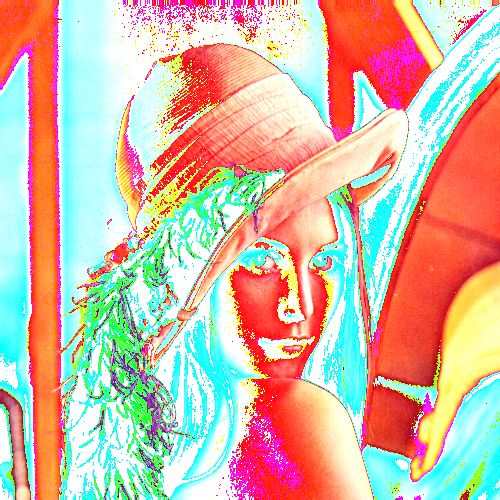

In [ ]:
cont_img = cv2.imread("/content/Lenna_(test_image).png")
cv2_imshow(cont_img)

rmin, rmax = 100, 200
smin, smax = 0, 255

s=(smax-smin)/(rmax-rmin)*(cont_img-rmin)+smin
cv2_imshow(s)

###**Digital Negative**

In [ ]:
img = np.array([[1,3,4],[4,5,2],[1,6,7]])
print(img)

L =8
negative_img = L-1-img
print("\n", negative_img)

[[1 3 4]
 [4 5 2]
 [1 6 7]]

 [[6 4 3]
 [3 2 5]
 [6 1 0]]


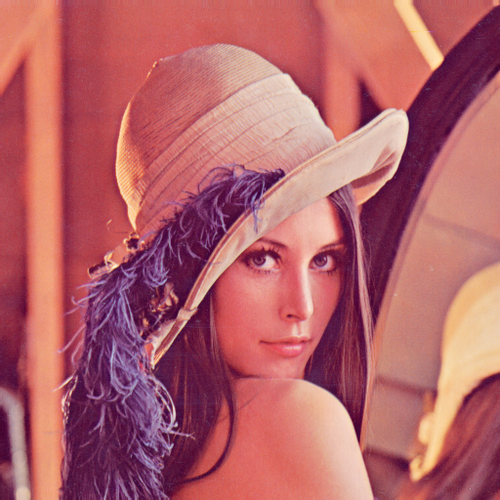

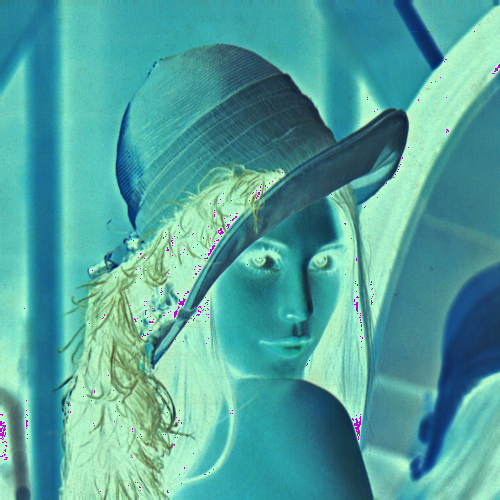

In [ ]:
img = cv2.imread("/content/Lenna_(test_image).png")
cv2_imshow(img)
L = 8
negative_img = L-1-img
cv2_imshow(negative_img)

###**Thresholding**

In [ ]:
img = np.array([[1,3,4],[4,5,2],[1,6,7]])
print(img)

img_thres = []
L =8
T = 4

for row in img:
    thres_row = []
    for pixel in row:
        if pixel < T:
            thres_row.append(0)
        else:
            thres_row.append(L - 1)
    img_thres.append(thres_row)

img_thres = np.array(img_thres)

print("\nThresholded image:\n", img_thres)

[[1 3 4]
 [4 5 2]
 [1 6 7]]

Thresholded image:
 [[0 0 7]
 [7 7 0]
 [0 7 7]]


In [ ]:
#Simplest way

img_thres = np.where(img < T, 0, L-1)

print(img_thres)

[[0 0 7]
 [7 7 0]
 [0 7 7]]


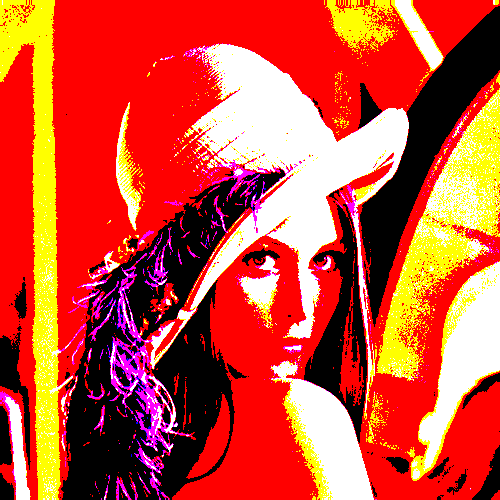

In [ ]:
#Real image
thres_img = cv2.imread("/content/Lenna_(test_image).png")
thres_img = np.where(thres_img < 128, 0, 255)
cv2_imshow(thres_img)

###**Using Python Image Libraby (PIL)**

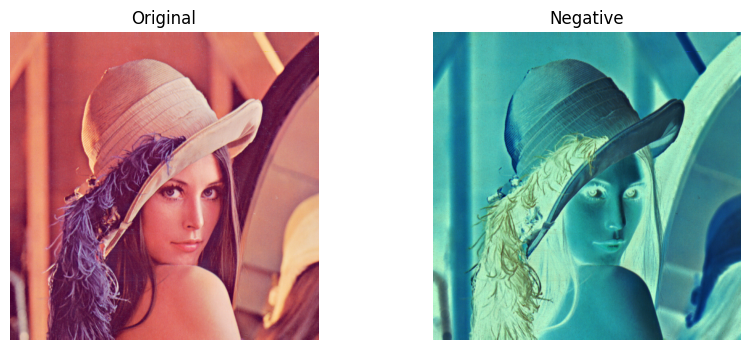

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = Image.open("/content/Lenna_(test_image).png")

# Convert to numpy
img_np = np.array(img)

# Negative transformation
L = 256
negative_img_np = (L - 1) - img_np

# Back to PIL image
negative_img = Image.fromarray(negative_img_np)

# Display
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Negative")
plt.imshow(negative_img)
plt.axis("off")

plt.show()


##**Histogram Processing**

In [11]:
import numpy as np
import matplotlib.pyplot as plt

img = np.array([[7, 3, 4],
                [4, 5, 2],
                [1, 6, 7]])

print("Original Image:\n", img)


Original Image:
 [[7 3 4]
 [4 5 2]
 [1 6 7]]


In [13]:
L = 8
hist = np.zeros(L, dtype=int)

# Calculate histogram
for pixel in img.flatten():
    hist[pixel] += 1

print("\nHistogram:")
for i in range(L):
    print(f"Gray level {i}: {hist[i]}")



Histogram:
Gray level 0: 0
Gray level 1: 1
Gray level 2: 1
Gray level 3: 1
Gray level 4: 2
Gray level 5: 1
Gray level 6: 1
Gray level 7: 2


In [7]:
total_pixels = img.size
pdf = hist / total_pixels
#print(total_pixels)

print("\nNormalized Histogram (PDF):")
for i in range(L):
    print(f"Gray level {i}: {pdf[i]:.3f}")

9

Normalized Histogram (PDF):
Gray level 0: 0.000
Gray level 1: 0.111
Gray level 2: 0.111
Gray level 3: 0.111
Gray level 4: 0.222
Gray level 5: 0.111
Gray level 6: 0.111
Gray level 7: 0.222


In [9]:
#Apply Equalization Formula: sk =(L−1)×CDF(rk)
equalized_levels = np.round((L - 1) * cdf).astype(int)

print("\nEqualized Gray Levels Mapping:")
for i in range(L):
    print(f"{i} → {equalized_levels[i]}")


Equalized Gray Levels Mapping:
0 → 0
1 → 1
2 → 2
3 → 2
4 → 4
5 → 5
6 → 5
7 → 7


In [10]:
equalized_img = np.zeros_like(img)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        equalized_img[i, j] = equalized_levels[img[i, j]]

print("\nHistogram Equalized Image:\n", equalized_img)


Histogram Equalized Image:
 [[7 2 4]
 [4 5 2]
 [1 5 7]]


###**Histogram Equalization**

In [8]:
#Compute CDF
cdf = np.cumsum(pdf)
print("\nCDF:")
for i in range(L):
    print(f"Gray level {i}: {cdf[i]:.3f}")


CDF:
Gray level 0: 0.000
Gray level 1: 0.111
Gray level 2: 0.222
Gray level 3: 0.333
Gray level 4: 0.556
Gray level 5: 0.667
Gray level 6: 0.778
Gray level 7: 1.000


##**Plotting Histogram**

In [14]:
# Negative image
negative_img = (L - 1) - img

# Histogram Equalization
hist = np.zeros(L)
for p in img.flatten():
    hist[p] += 1

pdf = hist / img.size
cdf = np.cumsum(pdf)
equalized_levels = np.round((L - 1) * cdf).astype(int)
equalized_img = equalized_levels[img]

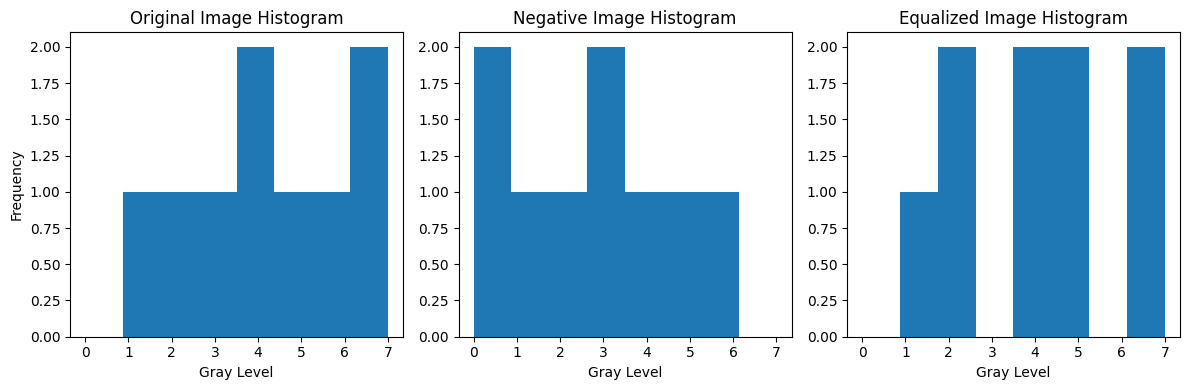

In [15]:
plt.figure(figsize=(12, 4))

# Original Image Histogram
plt.subplot(1, 3, 1)
plt.hist(img.flatten(), bins=L, range=(0, L-1))
plt.title("Original Image Histogram")
plt.xlabel("Gray Level")
plt.ylabel("Frequency")
plt.xticks(range(L))

# Negative Image Histogram
plt.subplot(1, 3, 2)
plt.hist(negative_img.flatten(), bins=L, range=(0, L-1))
plt.title("Negative Image Histogram")
plt.xlabel("Gray Level")
plt.xticks(range(L))

# Equalized Image Histogram
plt.subplot(1, 3, 3)
plt.hist(equalized_img.flatten(), bins=L, range=(0, L-1))
plt.title("Equalized Image Histogram")
plt.xlabel("Gray Level")
plt.xticks(range(L))

plt.tight_layout()
plt.show()

####**Interpolation**

Image resolution scaled but qulaity degrades

In [16]:
import numpy as np
from PIL import Image

def nearest_neighbor_upscale(image_path, scale_factor):
  img = Image.open (image_path)
  img_np = np. array(img)
  h, w = img_np.shape[:2]
  new_h, new_w = int(h * scale_factor), (w * scale_factor)
  upscaled_img = np.zeros((new_h, new_w, img_np.shape[2]), dtype=img_np.dtype) if img_np.ndim == 3 else np.zeros((new_h, new_w), dtype=img_np.dtype)
  for i in range(new_h):
    for j in range(new_w):
      src_i = int(i / scale_factor)
      src_j = int(j / scale_factor)
      upscaled_img[i, j] = img_np[src_i, src_j]
  return Image.fromarray(upscaled_img)

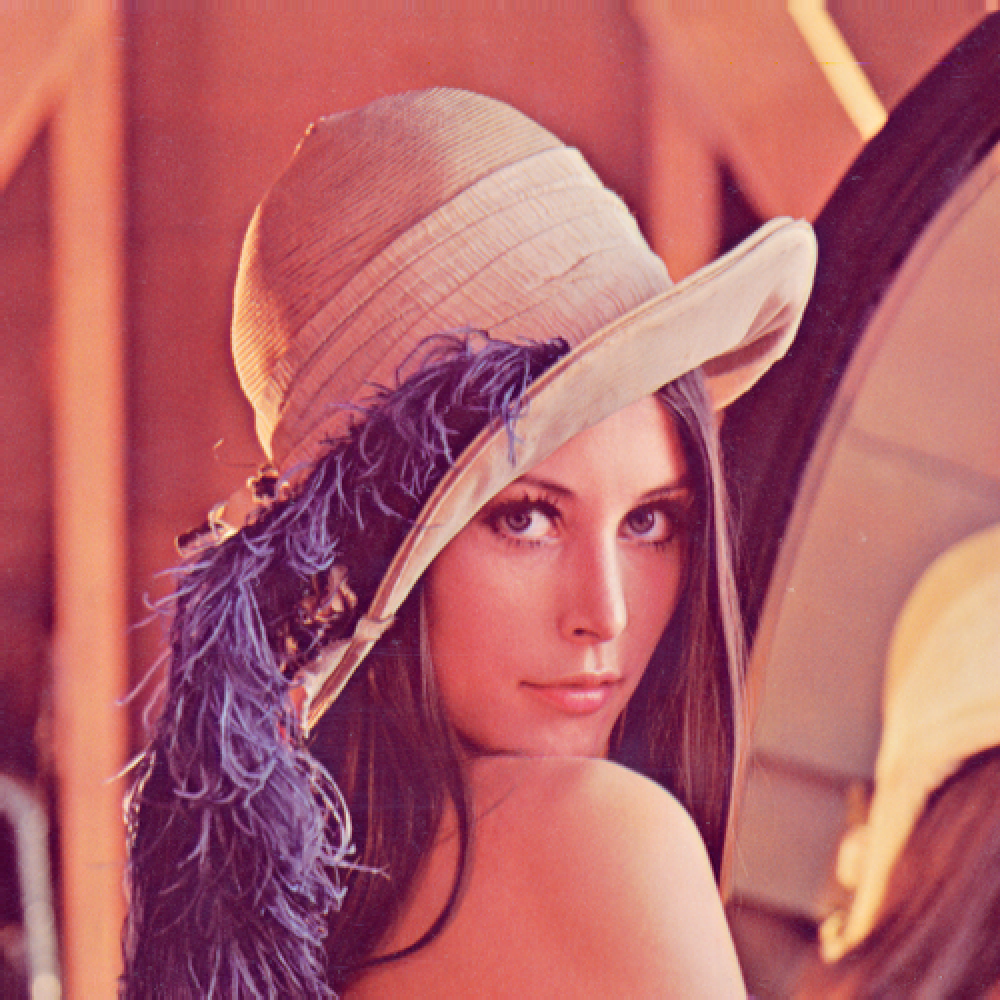

In [20]:
upscaled = nearest_neighbor_upscale("/content/Lenna_(test_image).png", 2)
#upscaled. save("upscaled.jpg")
upscaled